In [1]:
import pandas as pd 
df= pd.read_csv("cafe_sales.csv")

df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,200,4,Credit Card,Takeaway,08-09-2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,16-05-2023
2,TXN_4271903,Cookie,4,1,ERROR,Credit Card,In-store,19-07-2023
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,27-04-2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,11-06-2023


# DATA TYPES CONVERSION

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10003 non-null  object
 1   Item              9670 non-null   object
 2   Quantity          9865 non-null   object
 3   Price Per Unit    9824 non-null   object
 4   Total Spent       9829 non-null   object
 5   Payment Method    7424 non-null   object
 6   Location          6737 non-null   object
 7   Transaction Date  9844 non-null   object
dtypes: object(8)
memory usage: 625.3+ KB


In [3]:
#converting data types. 
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")  
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Transaction Date"] = pd.to_datetime (df["Transaction Date"], errors="coerce")
df["Total Spent"] = pd.to_numeric (df["Total Spent"], errors = "coerce") 

# errors="coerce" tells Pandas to convert invalid values into NaN (or NaT for dates) instead of throwing an error.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10003 non-null  object        
 1   Item              9670 non-null   object        
 2   Quantity          9524 non-null   float64       
 3   Price Per Unit    9470 non-null   float64       
 4   Total Spent       9500 non-null   float64       
 5   Payment Method    7424 non-null   object        
 6   Location          6737 non-null   object        
 7   Transaction Date  3744 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 625.3+ KB


# TREATING NULL VALUES

In [5]:
df.columns
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          503
Payment Method      2579
Location            3266
Transaction Date    6259
dtype: int64

In [6]:
df["Quantity"].describe()

count    9524.000000
mean        3.048824
std         2.467180
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max       200.000000
Name: Quantity, dtype: float64

In [7]:
null_count = df["Quantity"].isnull().mean() * 100
print(f"Number of null values Percentage in 'Quantity' column: {null_count}")

Number of null values Percentage in 'Quantity' column: 4.788563430970709


In [8]:
df.fillna({"Quantity": df["Quantity"].mean()}, inplace= True) 

In [9]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity               0
Price Per Unit       533
Total Spent          503
Payment Method      2579
Location            3266
Transaction Date    6259
dtype: int64

In [10]:
null_count = df["Price Per Unit"].isnull().mean() * 100
print(f"Number of null values Percentage in 'Price Per Unit' column: {null_count}")

null_count = df["Total Spent"].isnull().mean() * 100
print(f"Number of null values Percentage in 'Total Spent' column: {null_count}")

null_count = df["Payment Method"].isnull().mean() * 100
print(f"Number of null values Percentage in 'Payment Method' column: {null_count}")

null_count = df["Location"].isnull().mean() * 100
print(f"Number of null values Percentage in 'Location' column: {null_count}")

null_count = df["Transaction Date"].isnull().mean() * 100
print(f"Number of null values Percentage in 'Transaction Date' column: {null_count}")

null_count = df["Item"].isnull().mean() * 100
print(f"Number of null values Percentage in 'Item' column: {null_count}")

Number of null values Percentage in 'Price Per Unit' column: 5.328401479556133
Number of null values Percentage in 'Total Spent' column: 5.02849145256423
Number of null values Percentage in 'Payment Method' column: 25.78226532040388
Number of null values Percentage in 'Location' column: 32.65020493851844
Number of null values Percentage in 'Transaction Date' column: 62.57122863141058
Number of null values Percentage in 'Item' column: 3.3290012996101166


In [11]:
# Numeric columns with missing values can be filled with the mean.
df.fillna({"Price Per Unit" : df["Price Per Unit"].mean()}, inplace = True)

In [12]:
# Numeric columns with missing values can be filled with the mean.
df.fillna({"Total Spent" : df["Total Spent"].mean()}, inplace = True)

In [13]:
df["Payment Method"].value_counts(dropna = False)

Payment Method
NaN               2579
Digital Wallet    2291
Credit Card       2274
Cash              2260
ERROR              306
UNKNOWN            293
Name: count, dtype: int64

In [14]:
df["Payment Method"] = df["Payment Method"].replace("ERROR",pd.NA)
df["Location"] = df["Location"].replace ("ERROR", pd.NA)

In [15]:
#df.fillna({"Payment Method" : df["Payment Method"].mode()[0]}, inplace = True)

''' WE use "UNKNOWM" to fill the NAN values in "Payment Method" column because it is a 
categorical column and we do not want to fill it with the mode value as it may be misleading. ''' 

df.fillna({"Payment Method" : "UNKNOWN"}, inplace = True)
#df["Payment Method"].fillna("UNKNOWN", inplace = True)

In [16]:
#df["Total Spent"].value_counts(dropna = False)
#df["Location"].value_counts(dropna = False)
#df["Transaction Date"].value_counts(dropna = False)
df["Quantity"].value_counts(dropna = False)

Quantity
5.000000      2013
2.000000      1977
4.000000      1863
3.000000      1848
1.000000      1822
3.048824       479
200.000000       1
Name: count, dtype: int64

In [17]:
df.fillna({"Location" : "UNKNOWN"}, inplace = True)
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,200.0,4.000000,Credit Card,Takeaway,2023-08-09
1,TXN_4977031,Cake,4.0,3.0,12.000000,Cash,In-store,NaT
2,TXN_4271903,Cookie,4.0,1.0,8.959526,Credit Card,In-store,NaT
3,TXN_7034554,Salad,2.0,5.0,10.000000,UNKNOWN,UNKNOWN,NaT
4,TXN_3160411,Coffee,2.0,2.0,4.000000,Digital Wallet,In-store,2023-11-06


In [18]:
df["Transaction Date"]  = df["Transaction Date"].replace(" ", pd.NaT) 

In [19]:
df["Transaction Date"].value_counts(dropna = False)

Transaction Date
NaT           6259
2023-06-02      40
2023-05-01      38
2023-07-11      36
2023-07-08      36
              ... 
2023-03-04      17
2023-11-11      17
2023-12-05      16
2023-08-08      16
2023-11-03      14
Name: count, Length: 145, dtype: int64

In [20]:
df = df.dropna(subset = ["Transaction Date"])

In [21]:
df["Transaction Date"].value_counts(dropna = False)

Transaction Date
2023-06-02    40
2023-05-01    38
2023-07-11    36
2023-07-08    36
2023-12-01    36
              ..
2023-03-04    17
2023-11-11    17
2023-12-05    16
2023-08-08    16
2023-11-03    14
Name: count, Length: 144, dtype: int64

In [22]:
df["Item"].value_counts(dropna = False)

Item
Coffee      440
Cookie      434
Cake        432
Juice       426
Smoothie    426
Salad       415
Sandwich    410
Tea         392
NaN         135
UNKNOWN     129
ERROR       105
Name: count, dtype: int64

In [23]:
df["Item"] = df["Item"].replace("ERROR", "UNKNOWN")

In [24]:
df["Item"] = df["Item"].fillna("UNKNOWN")

In [25]:
df["Item"].value_counts(dropna = False)

Item
Coffee      440
Cookie      434
Cake        432
Smoothie    426
Juice       426
Salad       415
Sandwich    410
Tea         392
UNKNOWN     369
Name: count, dtype: int64

In [26]:
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.000000,200.0,4.0,Credit Card,Takeaway,2023-08-09
4,TXN_3160411,Coffee,2.000000,2.0,4.0,Digital Wallet,In-store,2023-11-06
6,TXN_4433211,UNKNOWN,3.000000,3.0,9.0,UNKNOWN,Takeaway,2023-06-10
10,TXN_2548360,Salad,5.000000,5.0,25.0,Cash,Takeaway,2023-07-11
12,TXN_7619095,Sandwich,2.000000,4.0,8.0,Cash,In-store,2023-03-05
13,TXN_9437049,Cookie,5.000000,1.0,5.0,UNKNOWN,Takeaway,2023-01-06
16,TXN_3765707,Sandwich,1.000000,4.0,4.0,UNKNOWN,UNKNOWN,2023-10-06
20,TXN_3522028,Smoothie,3.048824,4.0,20.0,Cash,In-store,2023-04-04
22,TXN_5132361,Sandwich,3.000000,4.0,12.0,Digital Wallet,Takeaway,2023-01-12
24,TXN_9400181,Sandwich,5.000000,4.0,20.0,Cash,In-store,2023-03-06


# HANDLING DUPLICATES 

In [27]:
df.duplicated(subset = "Transaction ID").sum()
#df[df.duplicated(subset='Transaction ID', keep=False)]

np.int64(2)

In [28]:
for col in df.columns:
    print(col, df[col].nunique())

Transaction ID 3742
Item 9
Quantity 7
Price Per Unit 8
Total Spent 19
Payment Method 4
Location 3
Transaction Date 144


In [29]:
# For columns with less than 20 unique values, we can print the value counts to understand the distribution of categories.
for col in df.columns:
    if df[col].nunique() < 20:
        print(f"\nColumn: {col}")
        print(df[col].value_counts())
        print("-" * 40) 


Column: Item
Item
Coffee      440
Cookie      434
Cake        432
Smoothie    426
Juice       426
Salad       415
Sandwich    410
Tea         392
UNKNOWN     369
Name: count, dtype: int64
----------------------------------------

Column: Quantity
Quantity
5.000000      776
2.000000      766
4.000000      676
1.000000      674
3.000000      663
3.048824      188
200.000000      1
Name: count, dtype: int64
----------------------------------------

Column: Price Per Unit
Price Per Unit
3.000000      910
4.000000      886
2.000000      457
1.000000      456
5.000000      435
1.500000      419
2.970591      180
200.000000      1
Name: count, dtype: int64
----------------------------------------

Column: Total Spent
Total Spent
6.000000      367
12.000000     361
4.000000      361
3.000000      354
15.000000     284
20.000000     268
8.000000      254
10.000000     199
2.000000      192
8.959526      175
5.000000      171
9.000000      166
16.000000     165
25.000000      97
1.000000       

In [30]:
df.duplicated().sum()
df[df.duplicated()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
10002,TXN_8153550,Cookie,2.0,1.0,2.0,Cash,Takeaway,2023-12-10


In [31]:
df = df.drop_duplicates (subset = "Transaction ID", keep = "first") 

In [32]:
df[df.duplicated()]
df.duplicated().sum()

np.int64(0)

In [33]:
df.reset_index(drop = True, inplace = True)

In [34]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

### FIXING QUANTITY VALUES AFFECTED BY MEAN IMPUTATION.

In [35]:
# Check unique values in the Quantity column to identify incorrect or decimal values
df["Quantity"].unique()

# Round decimal values in Quantity (caused by mean imputation) to the nearest whole number
df["Quantity"] = df["Quantity"].round()

# Convert Quantity column to integer since quantity should always be a whole number
df["Quantity"] = df["Quantity"].astype(int)

df["Quantity"].unique()

array([  2,   3,   5,   1,   4, 200])

In [36]:
df["Price Per Unit"].unique()

array([200.        ,   2.        ,   3.        ,   5.        ,
         4.        ,   1.        ,   1.5       ,   2.97059134])

In [37]:
df["Price Per Unit"].value_counts()

Price Per Unit
3.000000      910
4.000000      886
2.000000      456
1.000000      455
5.000000      435
1.500000      419
2.970591      180
200.000000      1
Name: count, dtype: int64

In [38]:
# 2.970591 is the mean value of "Price Per Unit" column which we used to fill the null values. 
# We can round it to 1 decimal place to make it more realistic and consistent with typical pricing formats.

df["Price Per Unit"] = df["Price Per Unit"].round(1)

In [39]:
df["Price Per Unit"].value_counts()

Price Per Unit
3.0      1090
4.0       886
2.0       456
1.0       455
5.0       435
1.5       419
200.0       1
Name: count, dtype: int64

In [40]:
# Checking value counts of 'Total Spent' revealed unexpected decimal values 
# (8.959526), indicating incorrect totals caused by earlier mean imputation
df["Total Spent"].value_counts(dropna = False)

Total Spent
6.000000     367
4.000000     361
12.000000    361
3.000000     354
15.000000    284
20.000000    268
8.000000     254
10.000000    199
2.000000     191
8.959526     175
5.000000     171
9.000000     166
16.000000    165
25.000000     97
1.000000      95
7.500000      87
4.500000      75
1.500000      72
Name: count, dtype: int64

In [41]:
# Total Spent = Quantity × Price Per Unit
# This ensures that incorrect or imputed values are corrected

df["Total Spent"] = df["Quantity"] * df["Price Per Unit"]
df["Total Spent"].value_counts()

Total Spent
12.0     428
6.0      420
3.0      382
15.0     332
4.0      329
20.0     261
8.0      243
9.0      228
10.0     186
2.0      182
5.0      168
16.0     154
4.5       96
1.0       91
25.0      91
7.5       82
1.5       67
400.0      1
600.0      1
Name: count, dtype: int64

# DATA QUALITY CHECK 

In [42]:
print("\n==== DATA QUALITY ASSESSMENT ====")

# CHECK FOR MISSING VALUES.
print("\n MISSING VALUES:\n")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# CHECK FOR DUPLICATES.
print(f"\n DUPLICATE ROWS: {df.duplicated().sum()}")


==== DATA QUALITY ASSESSMENT ====

 MISSING VALUES:

Series([], dtype: int64)

 DUPLICATE ROWS: 0


# HANDLING OUTLIERS

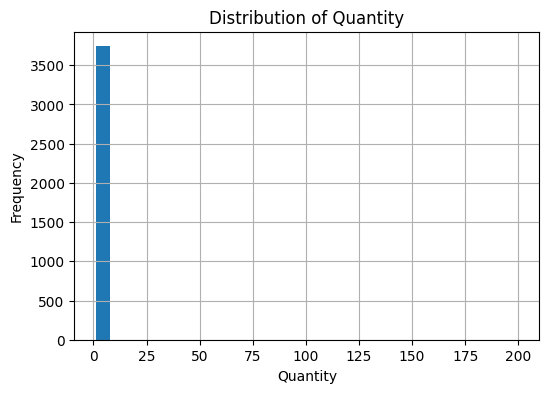

In [43]:
from scipy.stats import zscore
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# HISTOGRAM TO CHECK THE DISTRIBUTION OF THE QUANTITY COLUMN

plt.figure(figsize= (6,4))
df["Quantity"].hist(bins = 30)

plt.title ("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

# The data is right skewed, so we will use the IQR method to detect outliers.

In [44]:
df["Quantity"].is_monotonic_increasing
# pandas automatically sorts internally while calculating quantile. 

False

In [45]:
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,3742.000000,3742.000000,3742.000000,3742
mean,3.083645,2.988910,9.181053,2023-06-22 03:36:16.162479872
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-04-02 00:00:00
50%,3.000000,3.000000,8.000000,2023-06-12 00:00:00
75%,4.000000,4.000000,12.000000,2023-09-11 00:00:00
max,200.000000,200.000000,600.000000,2023-12-12 00:00:00
std,3.507460,3.454879,12.974793,NaN


In [46]:
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)
Q1, Q3

(np.float64(2.0), np.float64(4.0))

In [47]:
IQR = Q3 - Q1 
IQR

np.float64(2.0)

In [48]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

lower_limit, upper_limit 

print ("lower limit:", lower_limit)
print ("upper limit:", upper_limit)

# SO IF THE VALUE IS LESS THAN -1.0 OR GREATER THAN 7.0 THEN IT IS AN OUTLIER. 

lower limit: -1.0
upper limit: 7.0


In [49]:
# Filter rows where Quantity is below the lower limit or above the upper limit (IQR outliers)
df[(df["Quantity"] < lower_limit) | (df["Quantity"] > upper_limit)]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
3738,TXN_9659401,UNKNOWN,200,3.0,600.0,Digital Wallet,UNKNOWN,2023-02-06


In [50]:
# Remove the Outlier from your original dataset.

df = df[(df["Quantity"] > lower_limit) & (df["Quantity"] < upper_limit)] 
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,200.0,400.0,Credit Card,Takeaway,2023-08-09
1,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-11-06
2,TXN_4433211,UNKNOWN,3,3.0,9.0,UNKNOWN,Takeaway,2023-06-10
3,TXN_2548360,Salad,5,5.0,25.0,Cash,Takeaway,2023-07-11
4,TXN_7619095,Sandwich,2,4.0,8.0,Cash,In-store,2023-03-05
...,...,...,...,...,...,...,...,...
3736,TXN_2739140,Smoothie,4,4.0,16.0,UNKNOWN,In-store,2023-05-07
3737,TXN_7851634,UNKNOWN,4,4.0,16.0,UNKNOWN,UNKNOWN,2023-08-01
3739,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,UNKNOWN,2023-02-03
3740,TXN_7695629,Cookie,3,3.0,9.0,Digital Wallet,UNKNOWN,2023-02-12


In [51]:
df.tail(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
3731,TXN_6120851,Salad,5,5.0,25.0,Cash,Takeaway,2023-04-02
3732,TXN_3124078,Cake,4,3.0,12.0,UNKNOWN,In-store,2023-06-08
3733,TXN_8076061,Tea,4,1.5,6.0,Cash,In-store,2023-01-04
3734,TXN_5548914,Juice,2,3.0,6.0,Digital Wallet,In-store,2023-04-11
3735,TXN_3297457,Cake,2,3.0,6.0,UNKNOWN,UNKNOWN,2023-03-01
3736,TXN_2739140,Smoothie,4,4.0,16.0,UNKNOWN,In-store,2023-05-07
3737,TXN_7851634,UNKNOWN,4,4.0,16.0,UNKNOWN,UNKNOWN,2023-08-01
3739,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,UNKNOWN,2023-02-03
3740,TXN_7695629,Cookie,3,3.0,9.0,Digital Wallet,UNKNOWN,2023-02-12
3741,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-07-11


In [52]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,200.0,400.0,Credit Card,Takeaway,2023-08-09
1,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-11-06
2,TXN_4433211,UNKNOWN,3,3.0,9.0,UNKNOWN,Takeaway,2023-06-10
3,TXN_2548360,Salad,5,5.0,25.0,Cash,Takeaway,2023-07-11
4,TXN_7619095,Sandwich,2,4.0,8.0,Cash,In-store,2023-03-05


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3741 entries, 0 to 3741
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    3741 non-null   object        
 1   Item              3741 non-null   object        
 2   Quantity          3741 non-null   int64         
 3   Price Per Unit    3741 non-null   float64       
 4   Total Spent       3741 non-null   float64       
 5   Payment Method    3741 non-null   object        
 6   Location          3741 non-null   object        
 7   Transaction Date  3741 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 263.0+ KB


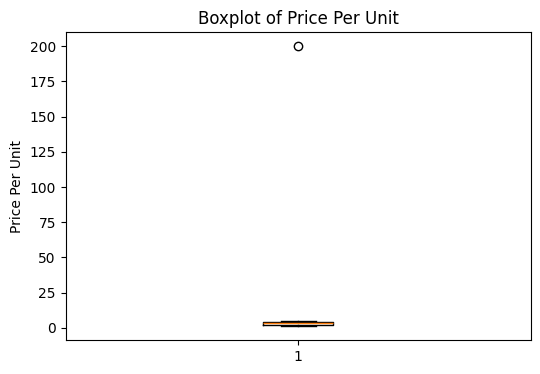

In [54]:
plt.figure(figsize= (6,4))
plt.boxplot(df["Price Per Unit"])
plt.title ("Boxplot of Price Per Unit")
plt.ylabel("Price Per Unit")
plt.show()

In [55]:
df["Price Per Unit"].is_monotonic_increasing

False

In [56]:
Q1 = df["Price Per Unit"].quantile(0.25)
Q3 = df["Price Per Unit"].quantile(0.75)
Q1, Q3

(np.float64(2.0), np.float64(4.0))

In [57]:
IQR = Q3 - Q1
IQR 

np.float64(2.0)

In [58]:
lower_limit = Q1 - 1.5 * IQR 
upper_limit = Q3 + 1.5 * IQR

lower_limit, upper_limit

(np.float64(-1.0), np.float64(7.0))

In [59]:
df = df[(df["Price Per Unit"] >= lower_limit) & (df["Price Per Unit"] <= upper_limit)]
df 

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-11-06
2,TXN_4433211,UNKNOWN,3,3.0,9.0,UNKNOWN,Takeaway,2023-06-10
3,TXN_2548360,Salad,5,5.0,25.0,Cash,Takeaway,2023-07-11
4,TXN_7619095,Sandwich,2,4.0,8.0,Cash,In-store,2023-03-05
5,TXN_9437049,Cookie,5,1.0,5.0,UNKNOWN,Takeaway,2023-01-06
...,...,...,...,...,...,...,...,...
3736,TXN_2739140,Smoothie,4,4.0,16.0,UNKNOWN,In-store,2023-05-07
3737,TXN_7851634,UNKNOWN,4,4.0,16.0,UNKNOWN,UNKNOWN,2023-08-01
3739,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,UNKNOWN,2023-02-03
3740,TXN_7695629,Cookie,3,3.0,9.0,Digital Wallet,UNKNOWN,2023-02-12


In [60]:
df = df[(df["Price Per Unit"] >= lower_limit) & (df["Price Per Unit"] <= upper_limit)]

In [61]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-11-06
2,TXN_4433211,UNKNOWN,3,3.0,9.0,UNKNOWN,Takeaway,2023-06-10
3,TXN_2548360,Salad,5,5.0,25.0,Cash,Takeaway,2023-07-11
4,TXN_7619095,Sandwich,2,4.0,8.0,Cash,In-store,2023-03-05
5,TXN_9437049,Cookie,5,1.0,5.0,UNKNOWN,Takeaway,2023-01-06


In [62]:
# Total Spent is a derived column calculated as Quantity × Price Per Unit.
# Therefore, outliers should not be removed directly from this column.
# Instead, outliers must be handled in the source columns (Quantity or Price Per Unit).
# After cleaning those columns, Total Spent was recalculated to ensure logical consistency.
df["Total Spent"].value_counts()

Total Spent
12.0    428
6.0     420
3.0     382
15.0    332
4.0     329
20.0    261
8.0     243
9.0     228
10.0    186
2.0     182
5.0     168
16.0    154
4.5      96
25.0     91
1.0      91
7.5      82
1.5      67
Name: count, dtype: int64

# SAVE THE CLEANED CSV

In [63]:
# Export cleaned dataset to CSV without saving index column
df.to_csv("cafe_sales_cleaned.csv", index = False)